In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification


Zadanie 1 — Pierwszy model klasyfikacyjny
 Dopasuj prosty model regresji logistycznej do danych syntetycznych i sprawdź, czego się nauczył.
Wygeneruj syntetyczne dane z jedną cechą i binarną etykietą klasy (0/1), z szumem.
Utwórz model regresji logistycznej i dopasuj go do danych.
Odczytaj współczynniki: wagę cechy i wyraz wolny.
Narysuj punkty (kolorem wg klasy) oraz dopasowaną krzywą sigmoidalną.

+
Zadanie 2 — Predykcja i ocena modelu
 Sprawdź, jak dobrze model klasyfikuje nowe obserwacje.
Podziel dane na treningowe i testowe.
Dopasuj model na danych treningowych.
Wykonaj predykcję klas i prawdopodobieństw na danych testowych.
Policz accuracy, precision, recall, F1 i oceń model.



In [15]:
X, y = make_classification(
    n_samples=100, 
    n_features=1, #jedna cecha
    n_informative=1, #jedna cecha ma znaczenie dla wyniku
    n_redundant=0, #wylaczamy niepotrzebne kopie 
    n_clusters_per_class=1, # Każda klasa (0 i 1) tworzy jedną zwartą grupę
    flip_y=0.1, #Szum: losowo zamień klasami 10% próbek
    random_state=42
)
#jedna cecha

In [16]:
df = pd.DataFrame({
    'Cecha_X': X.flatten(),  # .flatten() spłaszcza dane z formatu [[x], [x]] do [x, x]
    'Klasa_y': y
})
df

,Cecha_X,Klasa_y
0,0.819879,1
1,-1.242093,0
2,1.358547,0
3,1.813399,1
4,0.799142,1
...,...,...
95,-0.950264,0
96,-0.832703,0
97,-1.056758,0
98,1.664833,1


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

Użycie różnych liczb (jak 42 i 101) jest bardzo dobrą i powszechną praktyką. Pokazuje, że świadomie traktujesz generowanie danych oraz ich podział jako dwie odrębne operacje.

Różne wartości random_state rozdzielają od siebie dwa niezależne procesy losowe: tworzenie zbioru danych oraz jego podział na część treningową i testową. Pierwsza wartość (w make_classification) dba o to, aby model zawsze startował z tym samym układem cech i szumu. Druga wartość (w train_test_split) gwarantuje powtarzalne, stabilne losowanie próbek do testów, zapobiegając przypadkowemu wpływowi procesu generowania danych na ich późniejszy podział.

In [18]:
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [19]:
predictions = model.predict(X_test)
predictions

array([1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0])

In [20]:
#waga cechy 
model.coef_

array([[2.91586488]])

In [21]:
model.intercept_

array([0.06926589])

In [22]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90        14
           1       0.93      0.88      0.90        16

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [23]:
confusion_matrix(y_test,predictions)

array([[13,  1],
       [ 2, 14]])

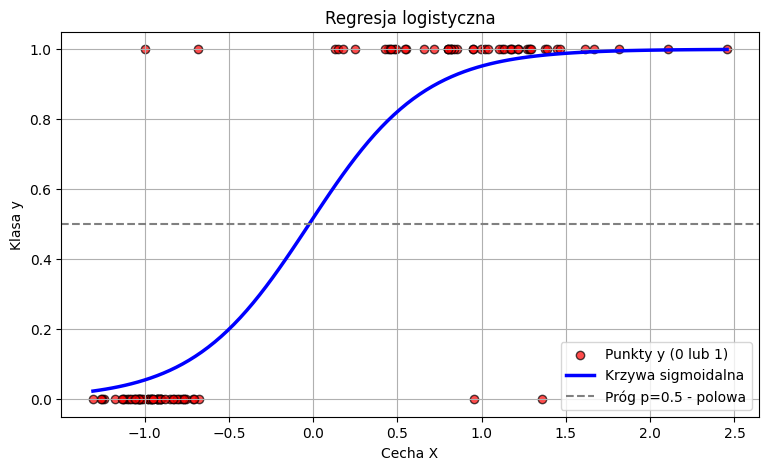

In [42]:
#tworzymy linie - 100 oznacza gladkosc 
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

# Prawdopodobieństwo z modelu z drugiej kolumny :1
y_proba = model.predict_proba(X_line)[:, 1]

plt.figure(figsize=(9, 5))

#Prawdziwe punkty 0 i 1
plt.scatter(
    X, y, color="red", alpha=0.7, edgecolors="k", label="Punkty y (0 lub 1)"
)

# Krzywa sigmoidalna z modelu
plt.plot(
    X_line, y_proba, color="blue", linewidth=2.5, label="Krzywa sigmoidalna"
)
#prog decyzyjny
plt.axhline(0.5, color="gray", linestyle="--", label="Próg p=0.5 - polowa")

plt.xlabel("Cecha X")
plt.ylabel("Klasa y")
plt.title("Regresja logistyczna")
plt.legend()
plt.grid(True)